### HyDE
What is HyDe?

HyDE (Hypothetical Document Embeddings) is a retrieval technique where, instead of embedding the user’s query directly, you first generate a hypothetical answer (document) to the query using an LLM — and then embed that hypothetical document to search your vector store.

HyDE bridges the gap between user intent and relevant content, especially when:

1. Queries are short
2. Language mismatch between query and documents
3.You want to retrieve based on answer content, not question words

In [30]:
from langchain_community.document_loaders import WikipediaLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma

In [31]:
# Loading data
loader=WikipediaLoader(query="Steve Jobs",load_max_docs=5)
deocuments=loader.load()

text_splitter=RecursiveCharacterTextSplitter(chunk_size=300,chunk_overlap=100)
docs=text_splitter.split_documents(documents=deocuments)
docs

[Document(metadata={'title': 'Steve Jobs', 'summary': 'Steven Paul Jobs (February 24, 1955 – October 5, 2011) was an American businessman, inventor, and investor best known for co-founding the technology company Apple Inc. Jobs was also the founder of NeXT and chairman and majority shareholder of Pixar. He was a pioneer of the personal computer revolution of the 1970s and 1980s, along with his early business partner and fellow Apple co-founder Steve Wozniak.\nJobs was born in San Francisco in 1955 and adopted shortly afterwards. He attended Reed College in 1972 before withdrawing that same year. In 1974, he traveled through India, seeking enlightenment before later studying Zen Buddhism. He and Wozniak co-founded Apple in 1976 to further develop and sell Wozniak\'s Apple I personal computer. Together, the duo gained fame and wealth a year later with production and sale of the Apple II, one of the first highly successful mass-produced microcomputers. \nJobs saw the commercial potential 

In [32]:
#build vector store

embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

from langchain.vectorstores import Chroma
## creating vector store
db = Chroma.from_documents(documents = docs,embedding=embeddings,persist_directory = "output/steve_jobs_for_hyde.db")


In [33]:
#set up llm for hypothetical answer

import os
from dotenv import load_dotenv
load_dotenv()

from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=init_chat_model("groq:llama-3.1-8b-instant")

In [34]:
##create the retriever
base_retriever=db.as_retriever(search_kwargs = {"k":5})

In [35]:
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import SystemMessagePromptTemplate, ChatPromptTemplate

#Generating a prompt for generating HyDE

def get_hyde_doc(query):
    template="""Imagine you are an expert writing a detailed explanation on the topic: '{query}'
    Create a hypothetical answer for the topic."""

    system_message_prompt=SystemMessagePromptTemplate.from_template(template=template)
    chat_prompt=ChatPromptTemplate.from_messages([system_message_prompt])
    messages=chat_prompt.format_prompt(query=query).to_messages()
    print(messages)
    response=llm.invoke(messages)
    hypo_doc=response.content
    return hypo_doc
    

In [36]:
query="When was Steve Jobs fired from Apple?"
print(get_hyde_doc(query=query))

[SystemMessage(content="Imagine you are an expert writing a detailed explanation on the topic: 'When was Steve Jobs fired from Apple?'\n    Create a hypothetical answer for the topic.", additional_kwargs={}, response_metadata={})]
**The Firing of Steve Jobs from Apple: A Brief History**

On September 17, 1985, Steve Jobs, the co-founder of Apple Inc., was indeed fired from the company he had helped create, marking a pivotal moment in the history of the technology industry.

**Background and Circumstances**

As you may know, Steve Jobs co-founded Apple in 1976 along with Steve Wozniak and Ronald Wayne. During the early years, Jobs played a crucial role in the development of innovative products such as the Apple I and Apple II computers. Apple's success was fueled by Jobs' passion for design, innovation, and simplicity.

However, as Apple continued to grow, disagreements began to arise between Jobs and John Sculley, the CEO of Apple at the time. Sculley, who was hired by Jobs himself in 

Until now, we have generated a hypothetical answer by connecting the query to the llm.
<br> Now, the hypothetical answer is sent as embeddings to the retriever and matched.

In [37]:
matched_doc=base_retriever.invoke(get_hyde_doc(query))
print(matched_doc)

[SystemMessage(content="Imagine you are an expert writing a detailed explanation on the topic: 'When was Steve Jobs fired from Apple?'\n    Create a hypothetical answer for the topic.", additional_kwargs={}, response_metadata={})]
[Document(metadata={'summary': 'Steven Paul Jobs (February 24, 1955 – October 5, 2011) was an American businessman, inventor, and investor best known for co-founding the technology company Apple Inc. Jobs was also the founder of NeXT and chairman and majority shareholder of Pixar. He was a pioneer of the personal computer revolution of the 1970s and 1980s, along with his early business partner and fellow Apple co-founder Steve Wozniak.\nJobs was born in San Francisco in 1955 and adopted shortly afterwards. He attended Reed College in 1972 before withdrawing that same year. In 1974, he traveled through India, seeking enlightenment before later studying Zen Buddhism. He and Wozniak co-founded Apple in 1976 to further develop and sell Wozniak\'s Apple I personal

### Langchain - HypothethicalDocumentEmbedder

In [38]:
from langchain.chains.hyde.base import HypotheticalDocumentEmbedder

from langchain.prompts import PromptTemplate
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains.combine_documents import create_stuff_documents_chain

# Step 1: Load and split documents
loader = TextLoader("data/langchain_crewai_dataset.txt")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(docs)

In [39]:
# Step 2: Set up LLM and embeddings

base_embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

In [40]:
# Step 3: HyDE Embedder using prompt_key='web_search'
hyde_embedding_function = HypotheticalDocumentEmbedder.from_llm(
    llm=llm,
    base_embeddings=base_embeddings,
    prompt_key="web_search"  
)

HypotheticalDocumentEmbedder<br><br>
A helper/utility that implements the HyDE pattern: query → hypothetical answer (LLM) → embedding (embedder). You get an object that you can call with a user query and it returns the embedding of the Hypothetical Document (not the embedding of the raw query). <br><br>
a base embedding model (base_embeddings) — used to compute embeddings of that hypothetical document. <br><br>
web_search might generate a short, concise. It is a prompt template. search-engine-style result.

According to the official documentation and LangChain source code (mapping in PROMPT_MAP), the default options are:

![Screenshot 2025-11-05 065846.png](<attachment:Screenshot 2025-11-05 065846.png>)
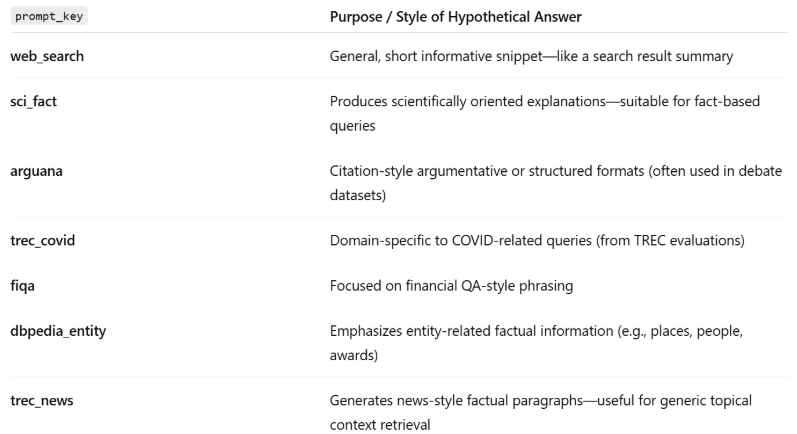

In [41]:
#Store documnents in Chroma with HyDE embeddings

vectorstore=Chroma.from_documents(
    documents=chunks,
    embedding=hyde_embedding_function,
    persist_directory="output/HyDE"
)

In [42]:
#Step 5: RAG Aswer generation
rag_prompt=PromptTemplate.from_template("""
Use the context below to answer the question.

Context:
{context}

Question: {input}
""")

rag_chain=create_stuff_documents_chain(llm=llm,prompt=rag_prompt)

In [43]:
# Step 6: Final RAG Pipeline
def hyde_rag_pipeline(query):
    matched_docs = vectorstore.similarity_search(query, k=4)
    print(matched_docs)
    response = rag_chain.invoke({
        "input": query,
        "context": matched_docs
    })
    return response

In [44]:
# Step 7: Run example query
query = "What memory modules does LangChain provide?"
answer = hyde_rag_pipeline(query)
print("Final Answer:\n", answer)

[Document(metadata={'source': 'data/langchain_crewai_dataset.txt'}, page_content='LangChain is an open-source framework designed for developing applications powered by large language models (LLMs). It simplifies the process of building, managing, and scaling complex chains of thought by abstracting prompt management, retrieval, memory, and agent orchestration. Developers can use'), Document(metadata={'source': 'data/langchain_crewai_dataset.txt'}, page_content='LangChain is an open-source framework designed for developing applications powered by large language models (LLMs). It simplifies the process of building, managing, and scaling complex chains of thought by abstracting prompt management, retrieval, memory, and agent orchestration. Developers can use'), Document(metadata={'source': 'data/langchain_crewai_dataset.txt'}, page_content='LangChain is an open-source framework designed for developing applications powered by large language models (LLMs). It simplifies the process of build

#### Custom Prompt

In [45]:
from langchain.prompts import PromptTemplate
custom = PromptTemplate.from_template(
    "Generate a concise hypothetical answer for this topic: {query}"
)

# Step 3: HyDE Embedder using prompt_key='web_search'
hyde_embedding_function = HypotheticalDocumentEmbedder.from_llm(
    llm=llm,
    base_embeddings=base_embeddings,
    custom_prompt=custom
)